![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Ejemplo predicción conjunto de test para envío a Kaggle

En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [1]:
import warnings
warnings.filterwarnings('ignore')



In [2]:
# Importación librerías
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn import metrics
import matplotlib.patches as mpatches
from sklearn.ensemble import BaggingRegressor

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Definición de 4 modelos diferentes: regresión logística, árbol de decisión,Navie Bayes y k vecinos más cercanos
models = {'lr': LinearRegression(),
          'dt': DecisionTreeRegressor(),
          'nb': GaussianNB(),
          'kn': KNeighborsRegressor()}



In [3]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

In [4]:
# Visualización datos de entrenamiento
dataTraining.head()

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,-10.795,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,-12.030,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,-9.661,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,3,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,-23.149,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,4,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,-7.294,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


In [5]:
# Visualización datos de test
dataTesting.head()

,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,440247,False,0.369,0.598,7,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
1,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,93933,False,0.171,0.997,7,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
2,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",213578,False,0.173,0.803,9,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
3,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,151387,False,0.683,0.511,6,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
4,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,236293,False,0.555,0.941,9,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


In [6]:
dataTraining.shape

(79800, 21)

## Preparación de los datos

In [7]:
# Eliminar columnas 'Unnamed:' y 'trackid'
dataTraining = dataTraining.loc[:, ~dataTraining.columns.str.startswith('Unnamed:')]
dataTraining = dataTraining.drop(columns=['track_id'], errors='ignore')


In [8]:
dataTraining.head()

,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,-10.795,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,-12.030,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,-9.661,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,-23.149,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,-7.294,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


In [9]:
dataTraining.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79800 entries, 0 to 79799
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artists           79800 non-null  object 
 1   album_name        79800 non-null  object 
 2   track_name        79800 non-null  object 
 3   duration_ms       79800 non-null  int64  
 4   explicit          79800 non-null  bool   
 5   danceability      79800 non-null  float64
 6   energy            79800 non-null  float64
 7   key               79800 non-null  int64  
 8   loudness          79800 non-null  float64
 9   mode              79800 non-null  int64  
 10  speechiness       79800 non-null  float64
 11  acousticness      79800 non-null  float64
 12  instrumentalness  79800 non-null  float64
 13  liveness          79800 non-null  float64
 14  valence           79800 non-null  float64
 15  tempo             79800 non-null  float64
 16  time_signature    79800 non-null  int64 

In [10]:
# Identificación de valores faltantes
valores_faltantes = dataTraining.isnull().sum()
print(valores_faltantes)

artists             0
album_name          0
track_name          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
popularity          0
dtype: int64


In [11]:
cat_cols = dataTraining.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"{col}: {dataTraining[col].unique()}\n")


artists: ['Love and Rockets' 'Filippa Giordano' 'Susumu Yokota' ... 'Keskin'
 'Amilcare Ponchielli;Gothenburg Symphony Orchestra;Neeme Järvi'
 'S N U G;Dyrean']

album_name: ['Love and Rockets' 'Filippa Giordano' 'Symbol' ... 'A Matter of Time'
 'BOZGUN' 'I Will Wait']

track_name: ['Motorcycle' 'Addio del passato - From "La traviata"'
 'Purple Rose Minuet' ... 'La Gioconda / Act 3: Dance Of The Hours'
 'Time of India' 'Back Then']

track_genre: ['goth' 'opera' 'idm' 'classical' 'techno' 'pop' 'acoustic' 'study'
 'trance' 'progressive-house' 'dance' 'forro' 'mpb' 'emo' 'kids' 'dubstep'
 'dancehall' 'rockabilly' 'children' 'cantopop' 'indie-pop' 'rock-n-roll'
 'punk' 'black-metal' 'pop-film' 'club' 'heavy-metal' 'hardcore' 'swedish'
 'chill' 'r-n-b' 'power-pop' 'trip-hop' 'piano' 'hip-hop' 'funk' 'rock'
 'hardstyle' 'j-dance' 'country' 'german' 'garage' 'malay' 'deep-house'
 'folk' 'death-metal' 'disney' 'hard-rock' 'disco' 'indian' 'pagode'
 'brazil' 'minimal-techno' 'punk-rock' 'blueg

In [12]:
for col in cat_cols:
    n = dataTraining[col].nunique()
    print(f"{col} ({n} únicos):")
    if n <= 50:
        print(dataTraining[col].unique())
    else:
        print("  -> Demasiados valores únicos para mostrar")
    print()


artists (25775 únicos):
  -> Demasiados valores únicos para mostrar

album_name (37315 únicos):
  -> Demasiados valores únicos para mostrar

track_name (55767 únicos):
  -> Demasiados valores únicos para mostrar

track_genre (114 únicos):
  -> Demasiados valores únicos para mostrar



In [13]:
# Convirtiendo la columna 'track_genre' en variables dummy
dataTraining = pd.get_dummies(dataTraining, columns=['track_genre'], drop_first=True)

In [14]:
# Número de artistas en la pista
dataTraining['num_artists'] = dataTraining['artists'].str.split(';').apply(len)

In [15]:
# Frecuencia del artista principal
main_artist = dataTraining['artists'].str.split(';').apply(lambda x: x[0].strip())
freq_artists = main_artist.value_counts(normalize=True)
dataTraining['main_artist_freq'] = main_artist.map(freq_artists)

In [16]:
# --- Eliminar columnas originales ---
dataTraining = dataTraining.drop(columns=['artists', 'album_name', 'track_name'])

In [17]:
dataTraining.shape

(79800, 130)

In [18]:
dataTraining.head()

,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,popularity,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music,num_artists,main_artist_freq
0,211533,False,0.305,0.8490,9,-10.795,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,22,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0.000013
1,196000,False,0.287,0.1900,7,-12.030,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,22,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0.0

In [19]:
# Tratar como categóricas
cols_cat = ['mode', 'time_signature', 'key'] 

dataTraining = pd.get_dummies(dataTraining, columns=cols_cat, drop_first=False) 

In [20]:
bool_cols = dataTraining.select_dtypes(include='bool').columns
dataTraining[bool_cols] = dataTraining[bool_cols].astype(int)

In [21]:
dataTraining.head()

,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music,num_artists,main_artist_freq,mode_0,mode_1,time_signature_0,time_signature_1,time_signature_3,time_signature_4,time_signature_5,key_0,key_1,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11
0,211533,0,0.305,0.8490,-10.795,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.000013,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
1,196000,0,0.287,0.1900,-12.030,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.000100,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,216506,0,0.583,0.5090,-9.661,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,37,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.000213,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,218346,0,0.163,0.0368,-23.149,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0.000075,0,1,0,0,1,0,0,0,0,0

Se eliminaron las columnas Unnamed:, trackid, album_name y track_name, se intuye que esta información no aportará señal predictiva relevante. Para la variable track_genre se aplicó One-Hot Encoding, generando una columna binaria por cada género musical. Para la variable artists, dado que una pista puede tener múltiples artistas separados por ;, se construyeron dos features: num_artists (número de artistas por pista) y main_artist_freq (frecuencia relativa del artista principal en el dataset). Finalmente, se eliminaron las columnas categóricas originales, dejando el dataset listo para el modelado.

## Pequeña Exploración

In [22]:
dataTraining.describe()

,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music,num_artists,main_artist_freq,mode_0,mode_1,time_signature_0,time_signature_1,time_signature_3,time_signature_4,time_signature_5,key_0,key_1,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11
count,7.980000e+04,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.000000,79800.0

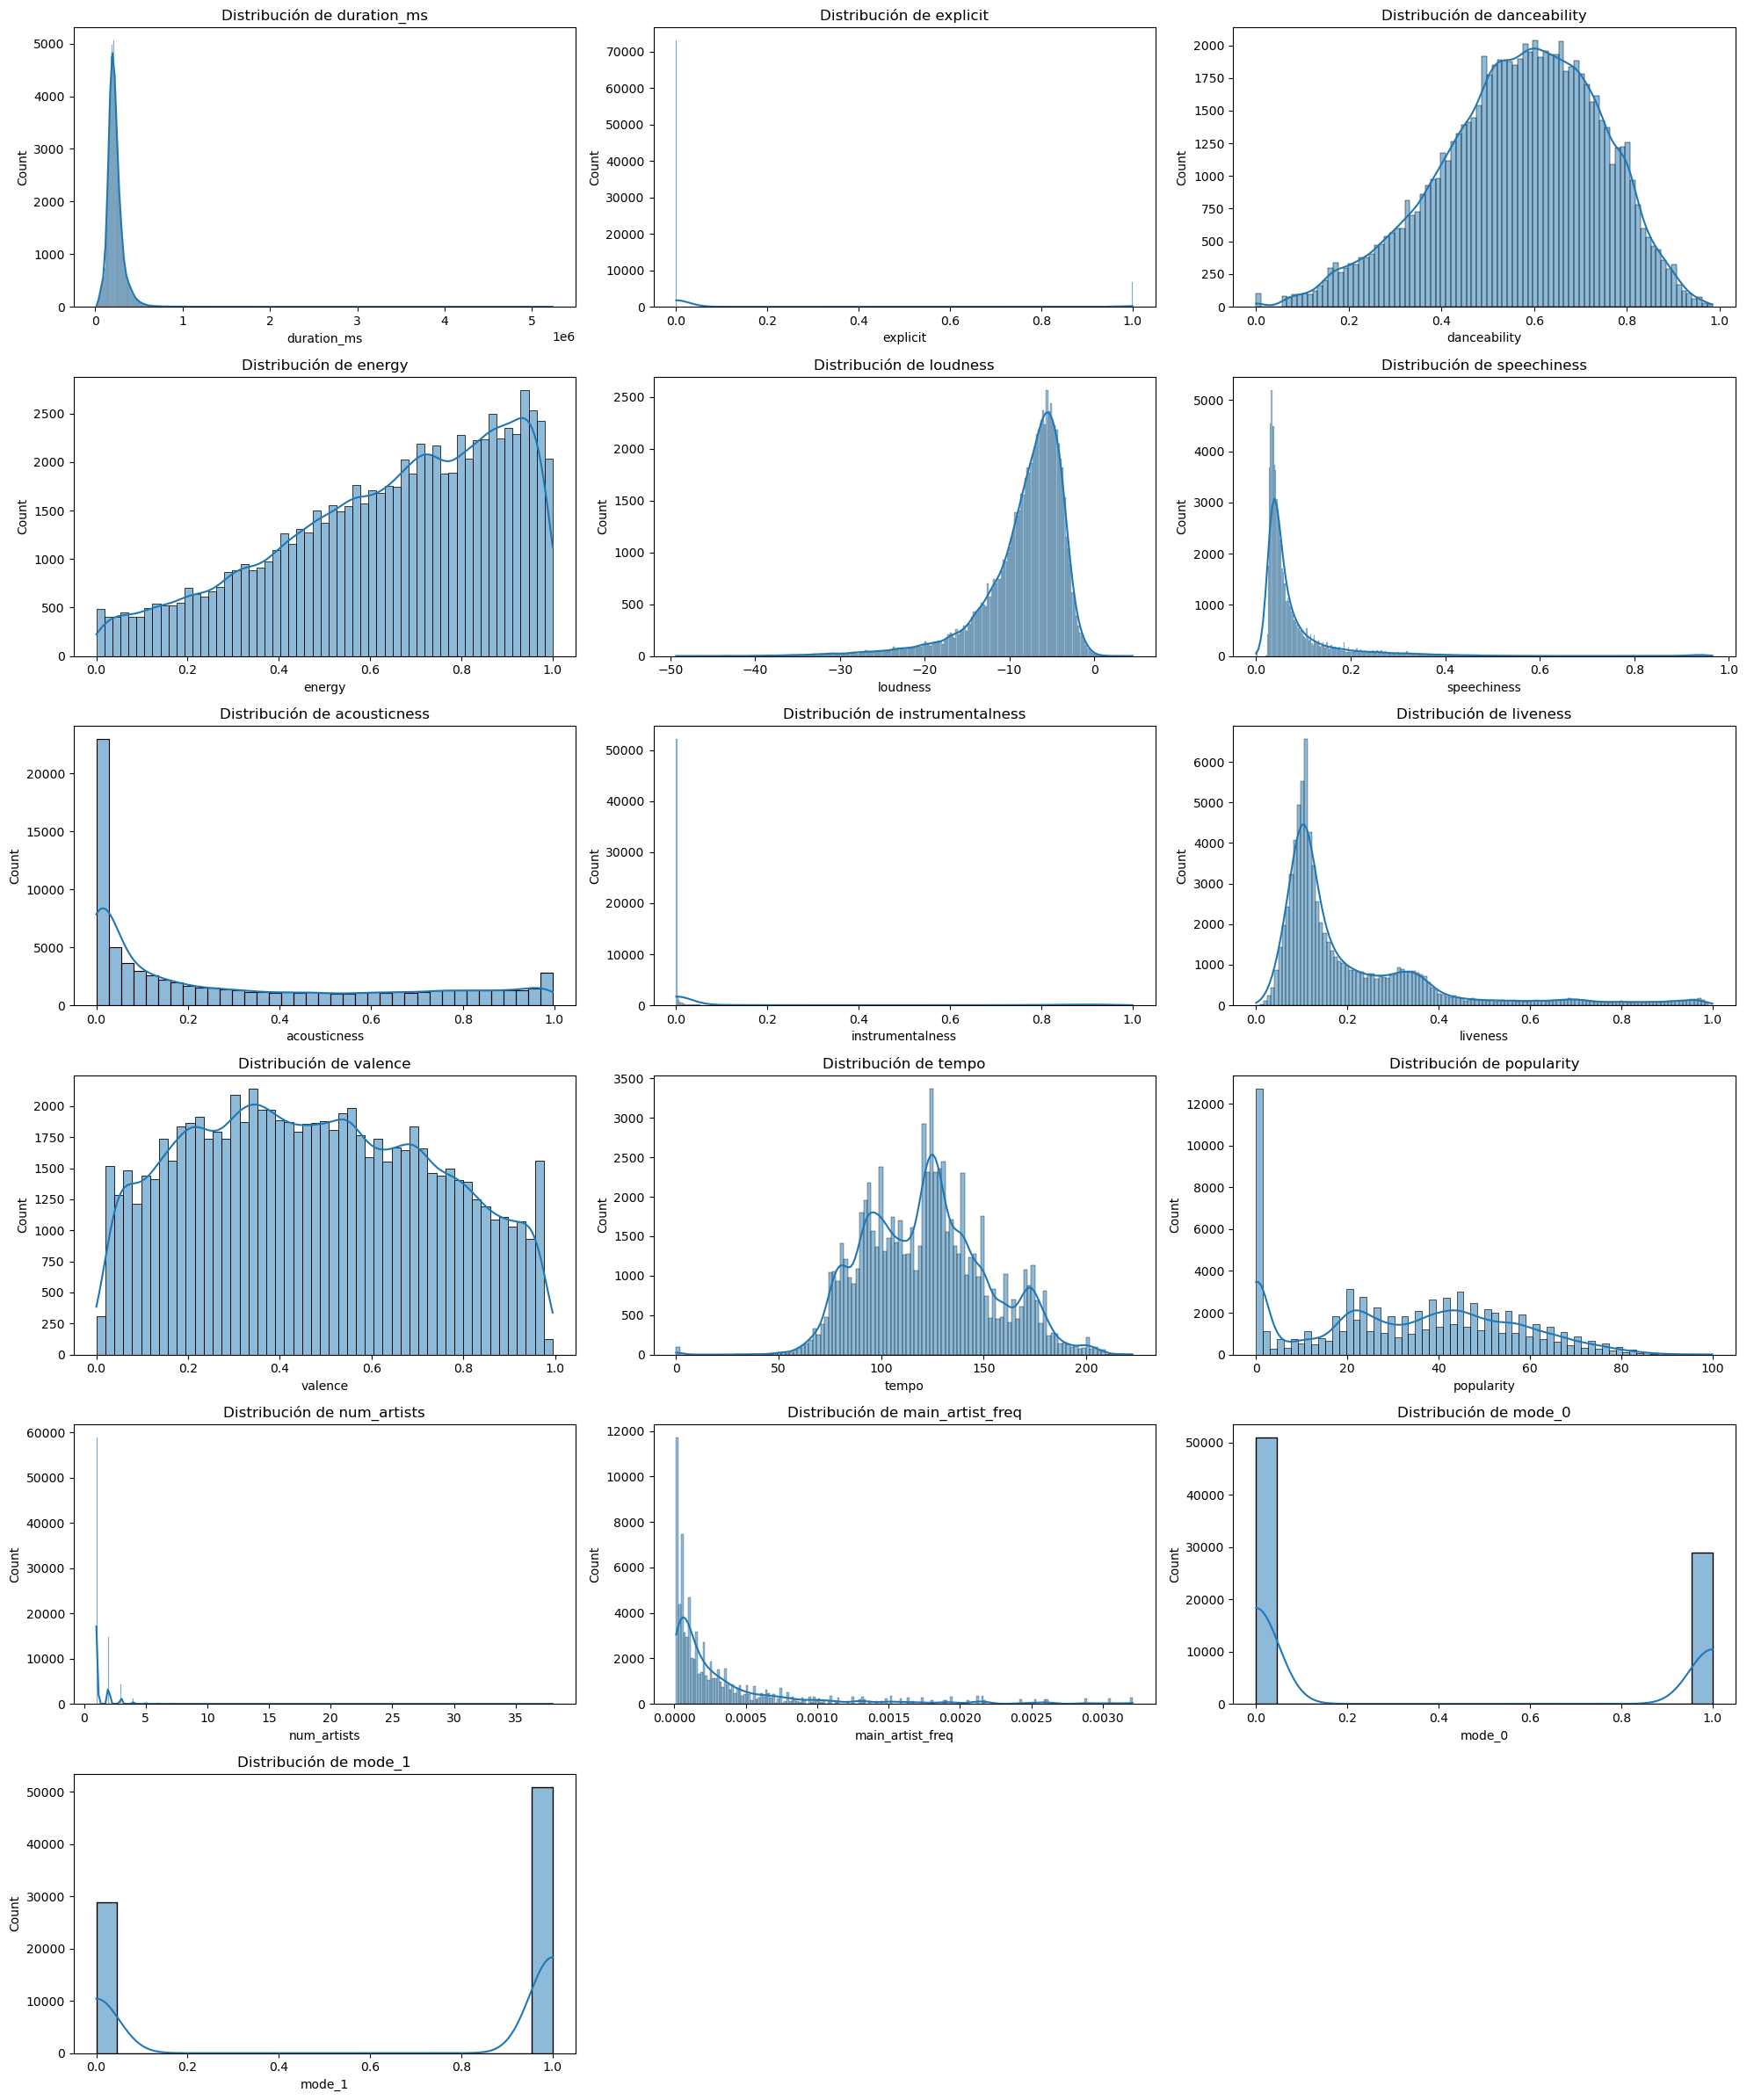

In [23]:
cols = [c for c in dataTraining.columns if not c.startswith('track_genre_')
        and not c.startswith('key')
        and not c.startswith('time_signature')]


n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=dataTraining, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


El dataset presenta un perfil típico de catálogo de streaming comercial. La mayoría de variables de audio se concentran en rangos específicos: canciones cortas, energéticas, grabadas en estudio, con voz, en modo mayor y en compás de 4/4. Esto sugiere un catálogo dominado por pop, rock y géneros mainstream.

Las variables más sesgadas (instrumentalness, speechiness, acousticness, liveness) indican que los casos "extremos", canciones instrumentales, en vivo o habladas, son una minoría clara. Por otro lado, danceability, valence y tempo muestran mayor variedad, lo que refleja diversidad de géneros y estados de ánimo dentro del catálogo.

La variable objetivo popularity está fuertemente sesgada hacia valores bajos: la mayoría de canciones son poco conocidas, con una cola delgada de canciones realmente populares. Esto es el mayor desafío para el modelado.

main_artist_freq y num_artists siguen distribuciones de ley de potencia, pocos artistas dominan el catálogo, y la mayoría de canciones son de un solo intérprete. Esto es consistente con cómo funciona la industria musical a escala global.

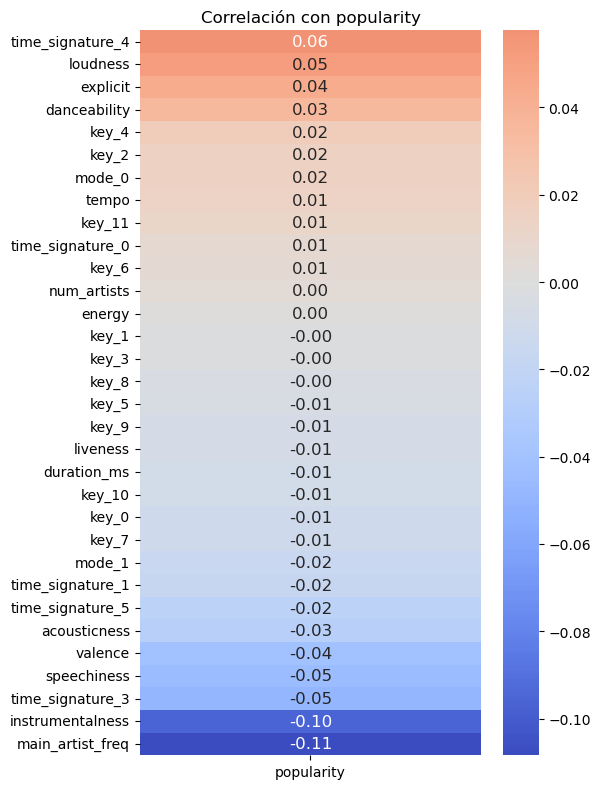

In [24]:
num_cols = [c for c in dataTraining.columns if not c.startswith('track_genre_')]

corr_target = dataTraining[num_cols].corr()[['popularity']].drop('popularity')
corr_target = corr_target.sort_values('popularity', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True, fmt='.2f', cmap='coolwarm',
            annot_kws={'size': 12}, center=0)
plt.title('Correlación con popularity')
plt.tight_layout()
plt.show()

Las correlaciones siguen siendo muy débiles (máximo 0.06). El encoding categórico de key, mode y time_signature no aportó señal nueva relevante, time_signature_4 subió apenas a 0.06, confirmando que el 4/4 es lo más común pero no predice popularidad. instrumentalness (-0.10) y main_artist_freq (-0.11) siguen siendo las variables con más señal, aunque igualmente débil. La popularidad no tiene relación lineal con ninguna feature de audio.

Se realizó una exploración inicial del conjunto de datos de entrenamiento (dataTraining) para entender su estructura y contenido. Se identificaron las variables categóricas del dataset: artists, album_name, track_name y track_genre. Para las columnas categóricas se inspeccionaron sus valores únicos, filtrando aquellas con más de 50 valores únicos para evitar saturar la salida. Adicionalmente, se visualizó la distribución de las variables numéricas mediante histogramas con curva de densidad (KDE), excluyendo las columnas derivadas del encoding. Para entender la relación entre variables, se calculó la correlación de cada variable numérica con la variable objetivo popularity.

# Modelado

In [25]:
# Separar features y variable objetivo
X = dataTraining.drop(columns=['popularity'])
y = dataTraining['popularity']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

## Bagging con librería

In [27]:
# Modelo
bagreg = BaggingRegressor(DecisionTreeRegressor(max_features='log2'),
                          n_estimators=10, bootstrap=True, oob_score=True, random_state=1)

bagreg.fit(X_train, y_train)
y_pred_b = bagreg.predict(X_test)

# Métricas
mse_b  = mean_squared_error(y_test, y_pred_b)
rmse_b = np.sqrt(mse_b)
mae_b  = mean_absolute_error(y_test, y_pred_b)
r2_b   = r2_score(y_test, y_pred_b)
oob_b  = bagreg.oob_score_

print(f"MSE:    {mse_b:.4f}")
print(f"RMSE:   {rmse_b:.4f}")
print(f"MAE:    {mae_b:.4f}")
print(f"R²:     {r2_b:.4f}")
print(f"OOB R²: {oob_b:.4f}")

MSE:    262.1791
RMSE:   16.1919
MAE:    11.4903
R²:     0.4689
OOB R²: 0.2777


## Random Forest

In [28]:
# Celda 4
rf = RandomForestRegressor(oob_score=True, random_state=1)

# rf = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=15,        
#     max_features='sqrt', 
#     n_jobs=-1,           
#     oob_score=True,
#     random_state=1
# )

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf

# Evaluación
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")
print(f"OOB R2: {rf.oob_score_}")  
print(f"MAE:  {mae_rf:.4f}")  

RMSE: 14.8608
R2:   0.5526
OOB R2: 0.5379890235933855
MAE:  10.0656


## Random Forest Calibrado

In [29]:
RF_CAL = dict(n_estimators=30, random_state=1, n_jobs=-1)  # base para calibrar, 
# n_estimators=50

# n_estimators 
estimator_range = range(10, 210, 20)  # menos valores
rmse_estimators = []
for n in estimator_range:
    rf = RandomForestRegressor(**{**RF_CAL, 'n_estimators': n})
    rmse_estimators.append(cross_val_score(rf, X_train, y_train, cv=3,  # cv=3 en vez de 5
                           scoring='neg_root_mean_squared_error').mean())

# # max_features (reducir rango)
# feature_range = range(1, X_train.shape[1] + 1, 2)  # saltos de 2
# rmse_features = []
# for f in feature_range:
#     rf = RandomForestRegressor(**{**RF_CAL, 'max_features': f})
#     rmse_features.append(cross_val_score(rf, X_train, y_train, cv=3,
#                          scoring='neg_root_mean_squared_error').mean())

# max_features: solo probar opciones clásicas en vez de todos los valores
feature_options = ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0]
rmse_features = []
for f in feature_options:
    rf = RandomForestRegressor(**{**RF_CAL, 'max_features': f})
    rmse_features.append(cross_val_score(rf, X_train, y_train, cv=3,
                         scoring='neg_root_mean_squared_error').mean())

# max_depth
depth_range = range(5, 25, 2)  # saltos de 2
rmse_depth = []
for d in depth_range:
    rf = RandomForestRegressor(**{**RF_CAL, 'max_depth': d})
    rmse_depth.append(cross_val_score(rf, X_train, y_train, cv=3,
                      scoring='neg_root_mean_squared_error').mean())

# min_samples_split
split_range = range(2, 20, 2)  # saltos de 2
rmse_split = []
for s in split_range:
    rf = RandomForestRegressor(**{**RF_CAL, 'min_samples_split': s})
    rmse_split.append(cross_val_score(rf, X_train, y_train, cv=3,
                      scoring='neg_root_mean_squared_error').mean())


In [30]:
# Mejores parámetros (max porque los valores son negativos, menos negativo = mejor RMSE)
best_n     = list(estimator_range)[rmse_estimators.index(max(rmse_estimators))]
#best_feat  = list(feature_range)[rmse_features.index(max(rmse_features))]
best_feat = feature_options[rmse_features.index(max(rmse_features))]
best_depth = list(depth_range)[rmse_depth.index(max(rmse_depth))]
best_split = list(split_range)[rmse_split.index(max(rmse_split))]

print(f"Mejor n_estimators:      {best_n}")
print(f"Mejor max_features:      {best_feat}")
print(f"Mejor max_depth:         {best_depth}")
print(f"Mejor min_samples_split: {best_split}")


Mejor n_estimators:      190
Mejor max_features:      0.7
Mejor max_depth:         23
Mejor min_samples_split: 2


In [31]:
# Modelo final
rf_final = RandomForestRegressor(
    n_estimators=best_n,
    max_features=best_feat,
    max_depth=best_depth,
    min_samples_split=best_split,
    oob_score=True,
    random_state=1,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)
y_pred_final = rf_final.predict(X_test)

rmse_rf_cal = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_rf_cal  = mean_absolute_error(y_test, y_pred_final)
r2_rf_cal   = r2_score(y_test, y_pred_final)

print(f"\nRMSE:   {rmse_rf_cal:.4f}")
print(f"MAE:    {mae_rf_cal:.4f}")
print(f"R²:     {r2_rf_cal:.4f}")
print(f"OOB R²: {rf_final.oob_score_:.4f}")



RMSE:   17.9411
MAE:    13.7491
R²:     0.3479
OOB R²: 0.3392


## XGBoost

In [32]:
clf = XGBRegressor(random_state=1)
clf

# Entrenamiento (fit) y desempeño del modelo XGBRegressor
clf.fit(X_train, y_train)
y_pred_xgb = clf.predict(X_test)

# Evaluación
mse_xgb  = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)

print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²:   {r2_xgb:.4f}")
print(f"MAE:  {mae_xgb:.4f}")

RMSE: 17.3074
R²:   0.3932
MAE:  12.3707


## XGBoost Calibrado

In [33]:
from xgboost import XGBRegressor

XGB_CAL = dict(random_state=1, n_jobs=-1, n_estimators=100)

# learning_rate
lr_range = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
rmse_lr = []
for lr in lr_range:
    xgb = XGBRegressor(**{**XGB_CAL, 'learning_rate': lr})
    rmse_lr.append(cross_val_score(xgb, X_train, y_train, cv=3,
                   scoring='neg_root_mean_squared_error').mean())

# gamma
gamma_range = [0, 0.1, 0.5, 1, 2, 5, 10]
rmse_gamma = []
for g in gamma_range:
    xgb = XGBRegressor(**{**XGB_CAL, 'gamma': g})
    rmse_gamma.append(cross_val_score(xgb, X_train, y_train, cv=3,
                      scoring='neg_root_mean_squared_error').mean())

# colsample_bytree
col_range = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
rmse_col = []
for c in col_range:
    xgb = XGBRegressor(**{**XGB_CAL, 'colsample_bytree': c})
    rmse_col.append(cross_val_score(xgb, X_train, y_train, cv=3,
                    scoring='neg_root_mean_squared_error').mean())

# max_depth
depth_range = [3, 4, 5, 6, 7, 8, 10]
rmse_depth_xgb = []
for d in depth_range:
    xgb = XGBRegressor(**{**XGB_CAL, 'max_depth': d})
    rmse_depth_xgb.append(cross_val_score(xgb, X_train, y_train, cv=3,
                           scoring='neg_root_mean_squared_error').mean())



In [34]:
# Mejores parámetros
best_lr    = lr_range[rmse_lr.index(max(rmse_lr))]
best_g     = gamma_range[rmse_gamma.index(max(rmse_gamma))]
best_col   = col_range[rmse_col.index(max(rmse_col))]
best_depth = depth_range[rmse_depth_xgb.index(max(rmse_depth_xgb))]

print(f"Mejor learning_rate:    {best_lr}")
print(f"Mejor gamma:            {best_g}")
print(f"Mejor colsample_bytree: {best_col}")
print(f"Mejor max_depth:        {best_depth}")

Mejor learning_rate:    0.5
Mejor gamma:            1
Mejor colsample_bytree: 1.0
Mejor max_depth:        10


In [35]:
# Modelo final
xgb_final = XGBRegressor(
    learning_rate=best_lr,
    gamma=best_g,
    colsample_bytree=best_col,
    max_depth=best_depth,
    random_state=1,
    n_jobs=-1
)
xgb_final.fit(X_train, y_train)
y_pred_xgb_final = xgb_final.predict(X_test)

rmse_xgb_final = np.sqrt(mean_squared_error(y_test, y_pred_xgb_final))
mae_xgb_final  = mean_absolute_error(y_test, y_pred_xgb_final)
r2_xgb_final   = r2_score(y_test, y_pred_xgb_final)

print(f"\nRMSE: {rmse_xgb_final:.4f}")
print(f"MAE:  {mae_xgb_final:.4f}")
print(f"R²:   {r2_xgb_final:.4f}")


RMSE: 16.7400
MAE:  11.3238
R²:   0.4323


# Kaggle

In [36]:
# Predicción del conjunto de test - acá se genera un número aleatorio como ejemplo
np.random.seed(42)
y_pred = pd.DataFrame(np.random.rand(dataTesting.shape[0]) * 100, index=dataTesting.index, columns=['Popularity'])

In [37]:
# Guardar predicciones en formato exigido en la competencia de kaggle
y_pred.to_csv('test_submission_file.csv', index_label='ID')
y_pred.head()

,Popularity
0,37.454012
1,95.071431
2,73.199394
3,59.865848
4,15.601864
